# Theorem 11 — Inverse Approximation and Exponential Decay

This notebook illustrates the inverse approximation statement for stable linear continuous-time RNNs.

The numerical experiment compares:

1. an exponentially decaying target;
2. a polynomially decaying target;
3. fixed versus shrinking stability gaps.

**Source:** Li, Han, E, and Li (2022), *Approximation and Optimization Theory for Linear Continuous-Time RNNs*, Theorem 11.


## 1. Theorem and experimental scope

For the constant input $e_i$, define

$$
y_i(t)=H_t(e_i).
$$

Theorem 11 states that if the derivatives $y_i^{(k)}$ can be approximated uniformly on $[0,\infty)$ by linear RNNs whose parameters remain uniformly bounded and whose state matrices possess a common stability margin, then

$$
e^{\beta t}y_i^{(k)}(t)\to 0
\qquad
(t\to\infty).
$$

Equivalently,

$$
y_i^{(k)}(t)=o(e^{-\beta t}).
$$

The experiment does not prove the theorem. It illustrates why the common stability gap is essential.

**Source:** Li et al. (2022), Theorem 11 and its proof.


## 2. Numerical approximation model

We approximate a target kernel $\rho$ by

$$
\widehat\rho_m(t)
=
\sum_{j=1}^m a_j e^{-\lambda_j t}.
$$

For fixed rates $\lambda_j$, the coefficients are found by discrete least squares:

$$
\min_{a\in\mathbb R^m}
\|\Phi a-r\|_2^2,
\qquad
\Phi_{ij}=e^{-\lambda_j t_i}.
$$

Two rate families are compared:

- **fixed gap:** $\lambda_j\ge \beta$;
- **shrinking gap:** $\lambda_{\min}(m)=1/m$.

The first satisfies a common stability margin. The second allows increasingly slow time scales as $m$ grows.


## 3. Load saved experiment results


In [16]:
from pathlib import Path

import pandas as pd
from IPython.display import Image, display

PROJECT_ROOT = Path.cwd().resolve().parent

FIGURE_DIR = PROJECT_ROOT / "outputs" / "figures"
TABLE_PATH = (
    PROJECT_ROOT
    / "outputs"
    / "tables"
    / "theorem11_inverse_decay_results.csv"
)

results = pd.read_csv(TABLE_PATH)
results


,width,exponential_fixed_gap_error,polynomial_fixed_gap_error,polynomial_shrinking_gap_error,shrinking_gap_lambda_min
0,2,2.454936e-01,0.112496,3.181705e-01,0.500000
1,3,9.169279e-02,0.028232,4.863566e-02,0.333333
2,5,1.570514e-03,0.030446,2.008098e-03,0.200000
3,8,1.353110e-04,0.016206,2.855385e-04,0.125000
4,10,2.915146e-06,0.011036,4.450707e-05,0.100000
5,15,1.351752e-08,0.005460,5.053517e-08,0.066667
6,20,3.283107e-11,0.003444,9.087620e-12,0.050000
7,30,2.282619e-13,0.002298,6.583623e-14,0.033333


## 4. Fixed stability gap: target comparison

The first figure compares

$$
\rho_{\exp}(t)=e^{-2t},
\qquad
\rho_{\mathrm{poly}}(t)=\frac{1}{(1+t)^2}.
$$

Both targets are approximated by exponential sums whose decay rates satisfy $\lambda_j\ge\beta$.

For each width $m$, the plot shows the maximum absolute kernel error on the discretized interval $[0,20]$:

$$
E_m
=
\max_{t\in[0,20]}
\left|
\rho(t)-\widehat\rho_m(t)
\right|.
$$

The horizontal axis is the RNN width $m$, while the vertical axis shows $E_m$ on a logarithmic scale.

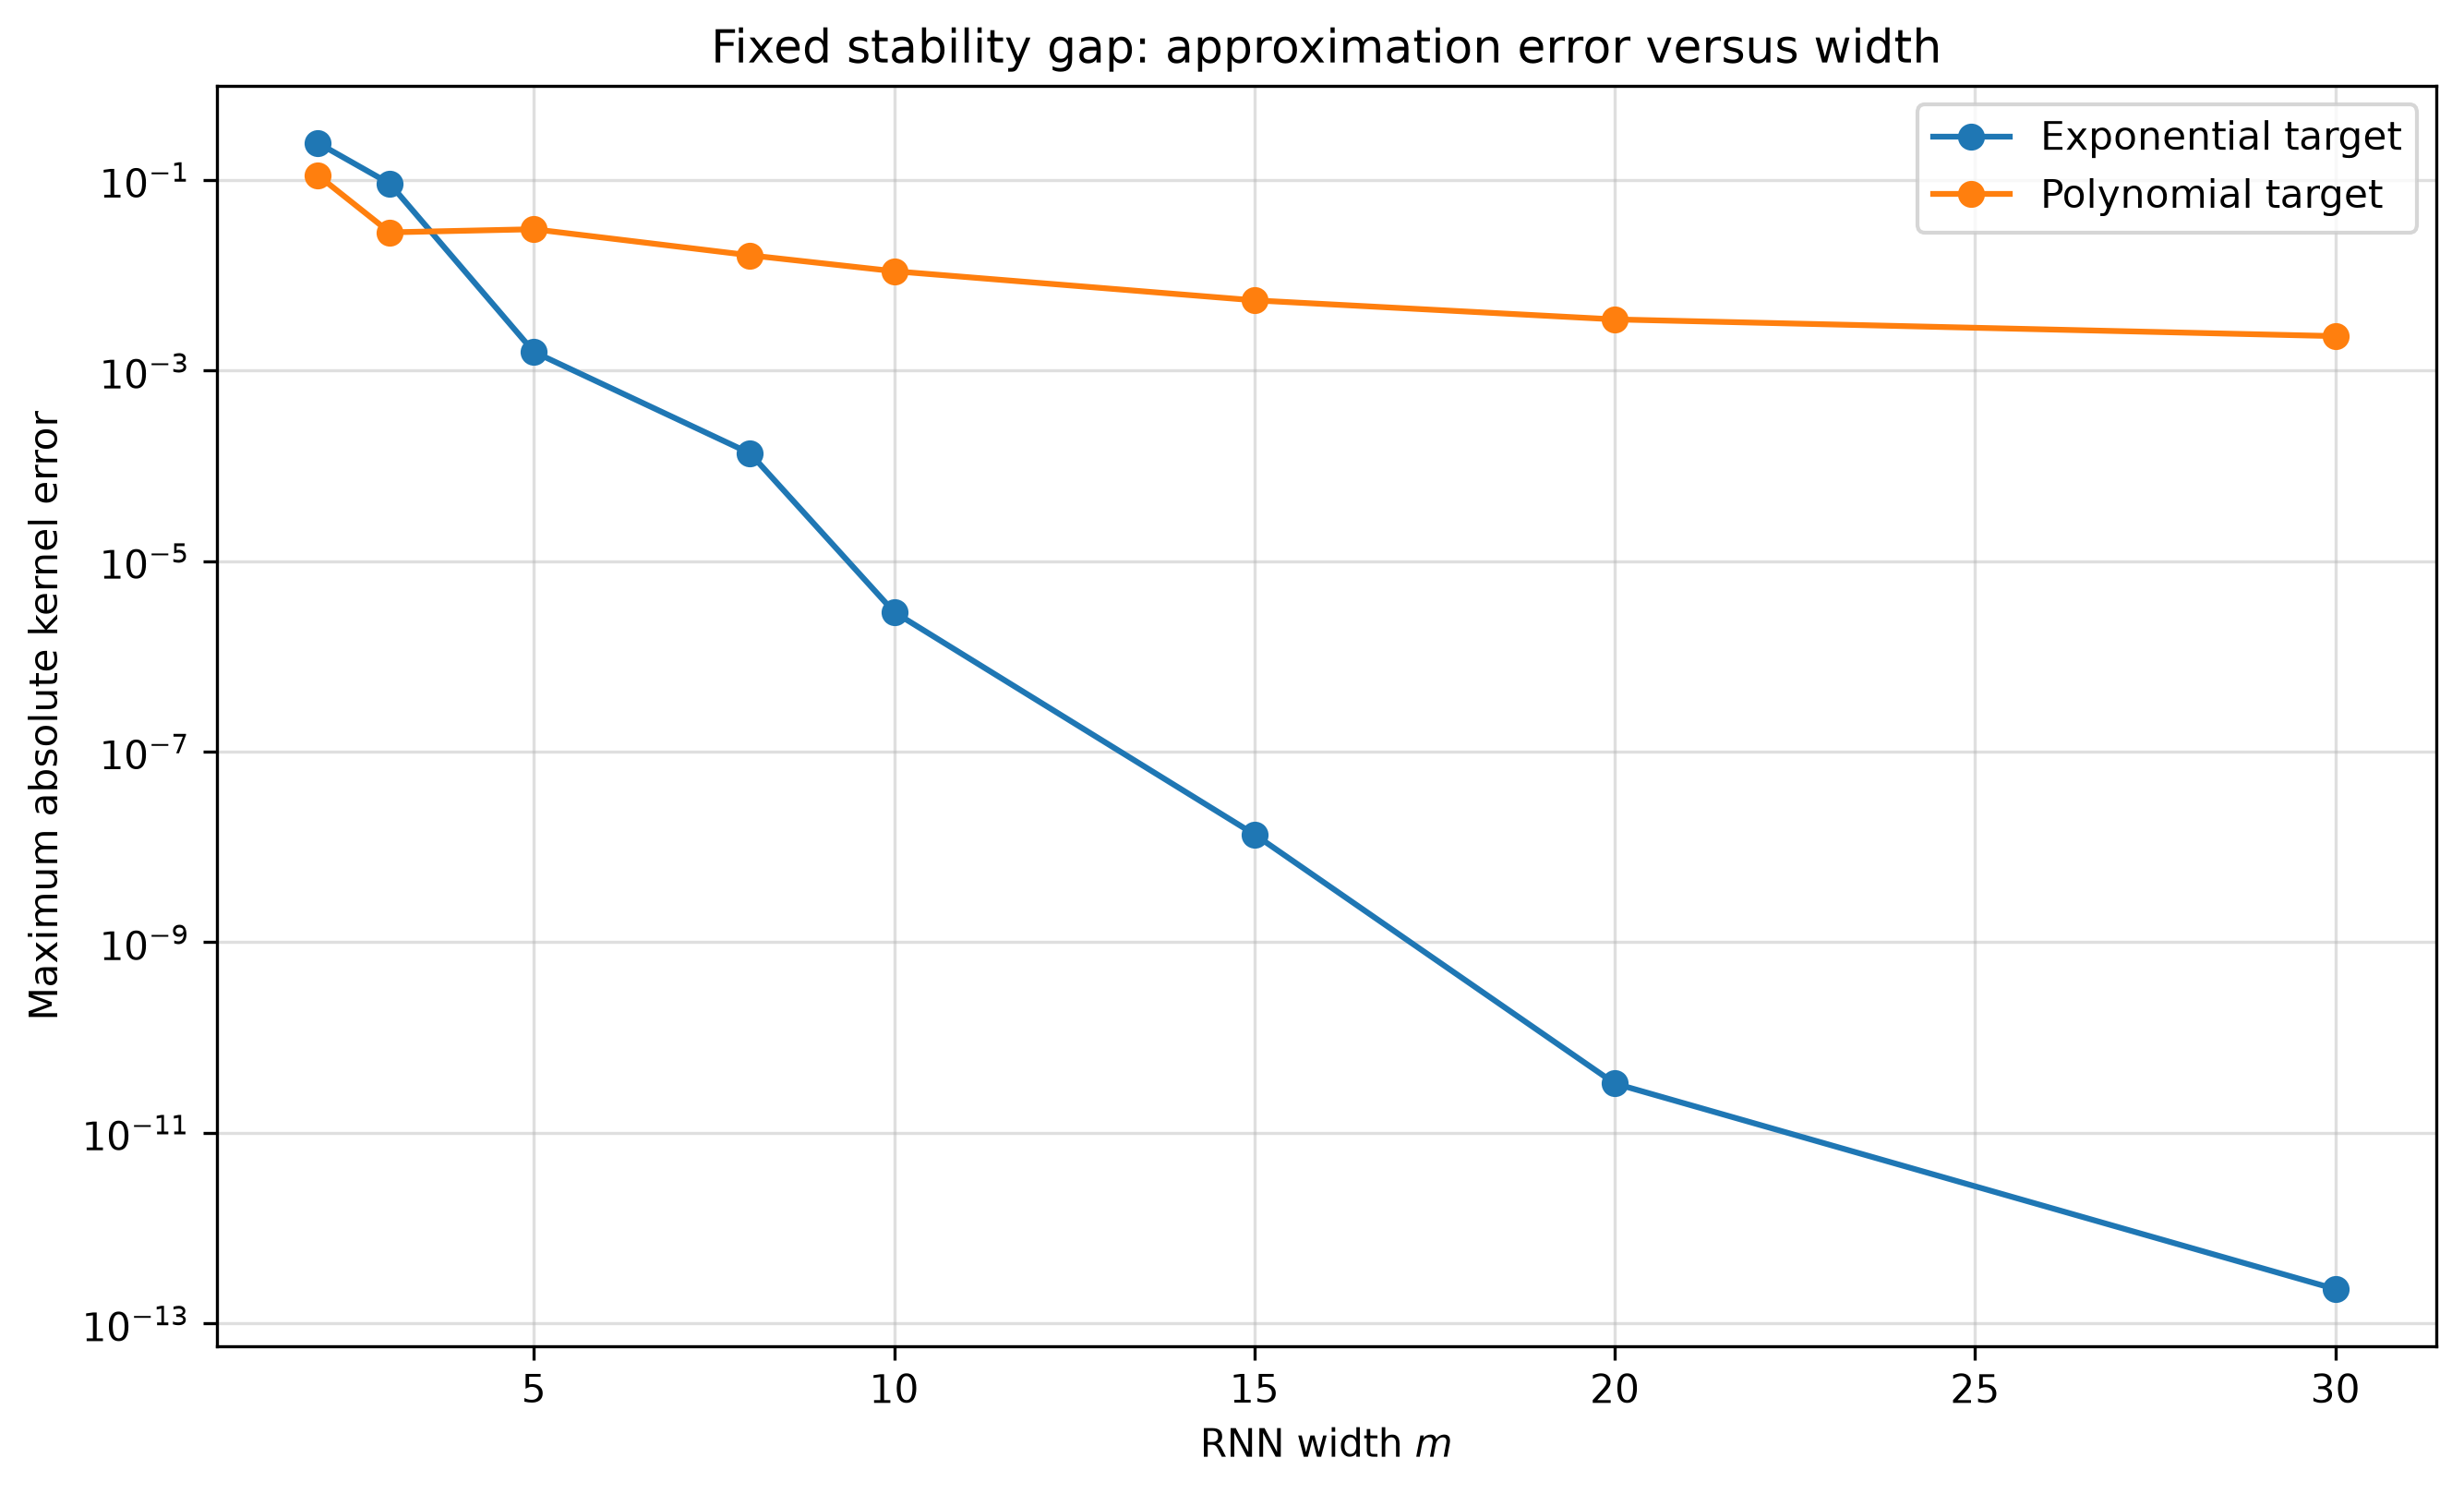

In [17]:
display(
    Image(
        filename=str(
            FIGURE_DIR
            / "theorem11_fixed_gap_target_comparison.png"
        ),
        width=20,
    )
)

### Interpretation

The exponential target is approximated increasingly well as the width $m$ grows. Its error decreases by many orders of magnitude and reaches approximately machine precision for large $m$. This is expected because the target itself belongs to the class of exponentially decaying kernels represented by the chosen basis.

For the polynomial target, the error decreases only slowly and appears to level off around $10^{-3}$. The fixed stability gap restricts all basis functions to decay at least as fast as $e^{-\beta t}$, whereas the target decays only polynomially. Increasing the width therefore improves the finite-interval fit, but it does not remove the mismatch in tail behavior.

The experiment illustrates the inverse statement behind Theorem 11: under a common stability margin, exponentially decaying targets are compatible with the model class, while slowly decaying targets remain fundamentally harder to approximate globally.

## 5. Weighted decay criterion

The theorem's conclusion is tested through

$$
e^{\beta t}|\rho(t)|.
$$

For the exponential target with $\beta=1$,

$$
e^{\beta t}\rho_{\exp}(t)=e^{-t}\to0.
$$

For the polynomial target,

$$
e^{\beta t}\rho_{\mathrm{poly}}(t)
=
\frac{e^t}{(1+t)^2}
\to\infty.
$$


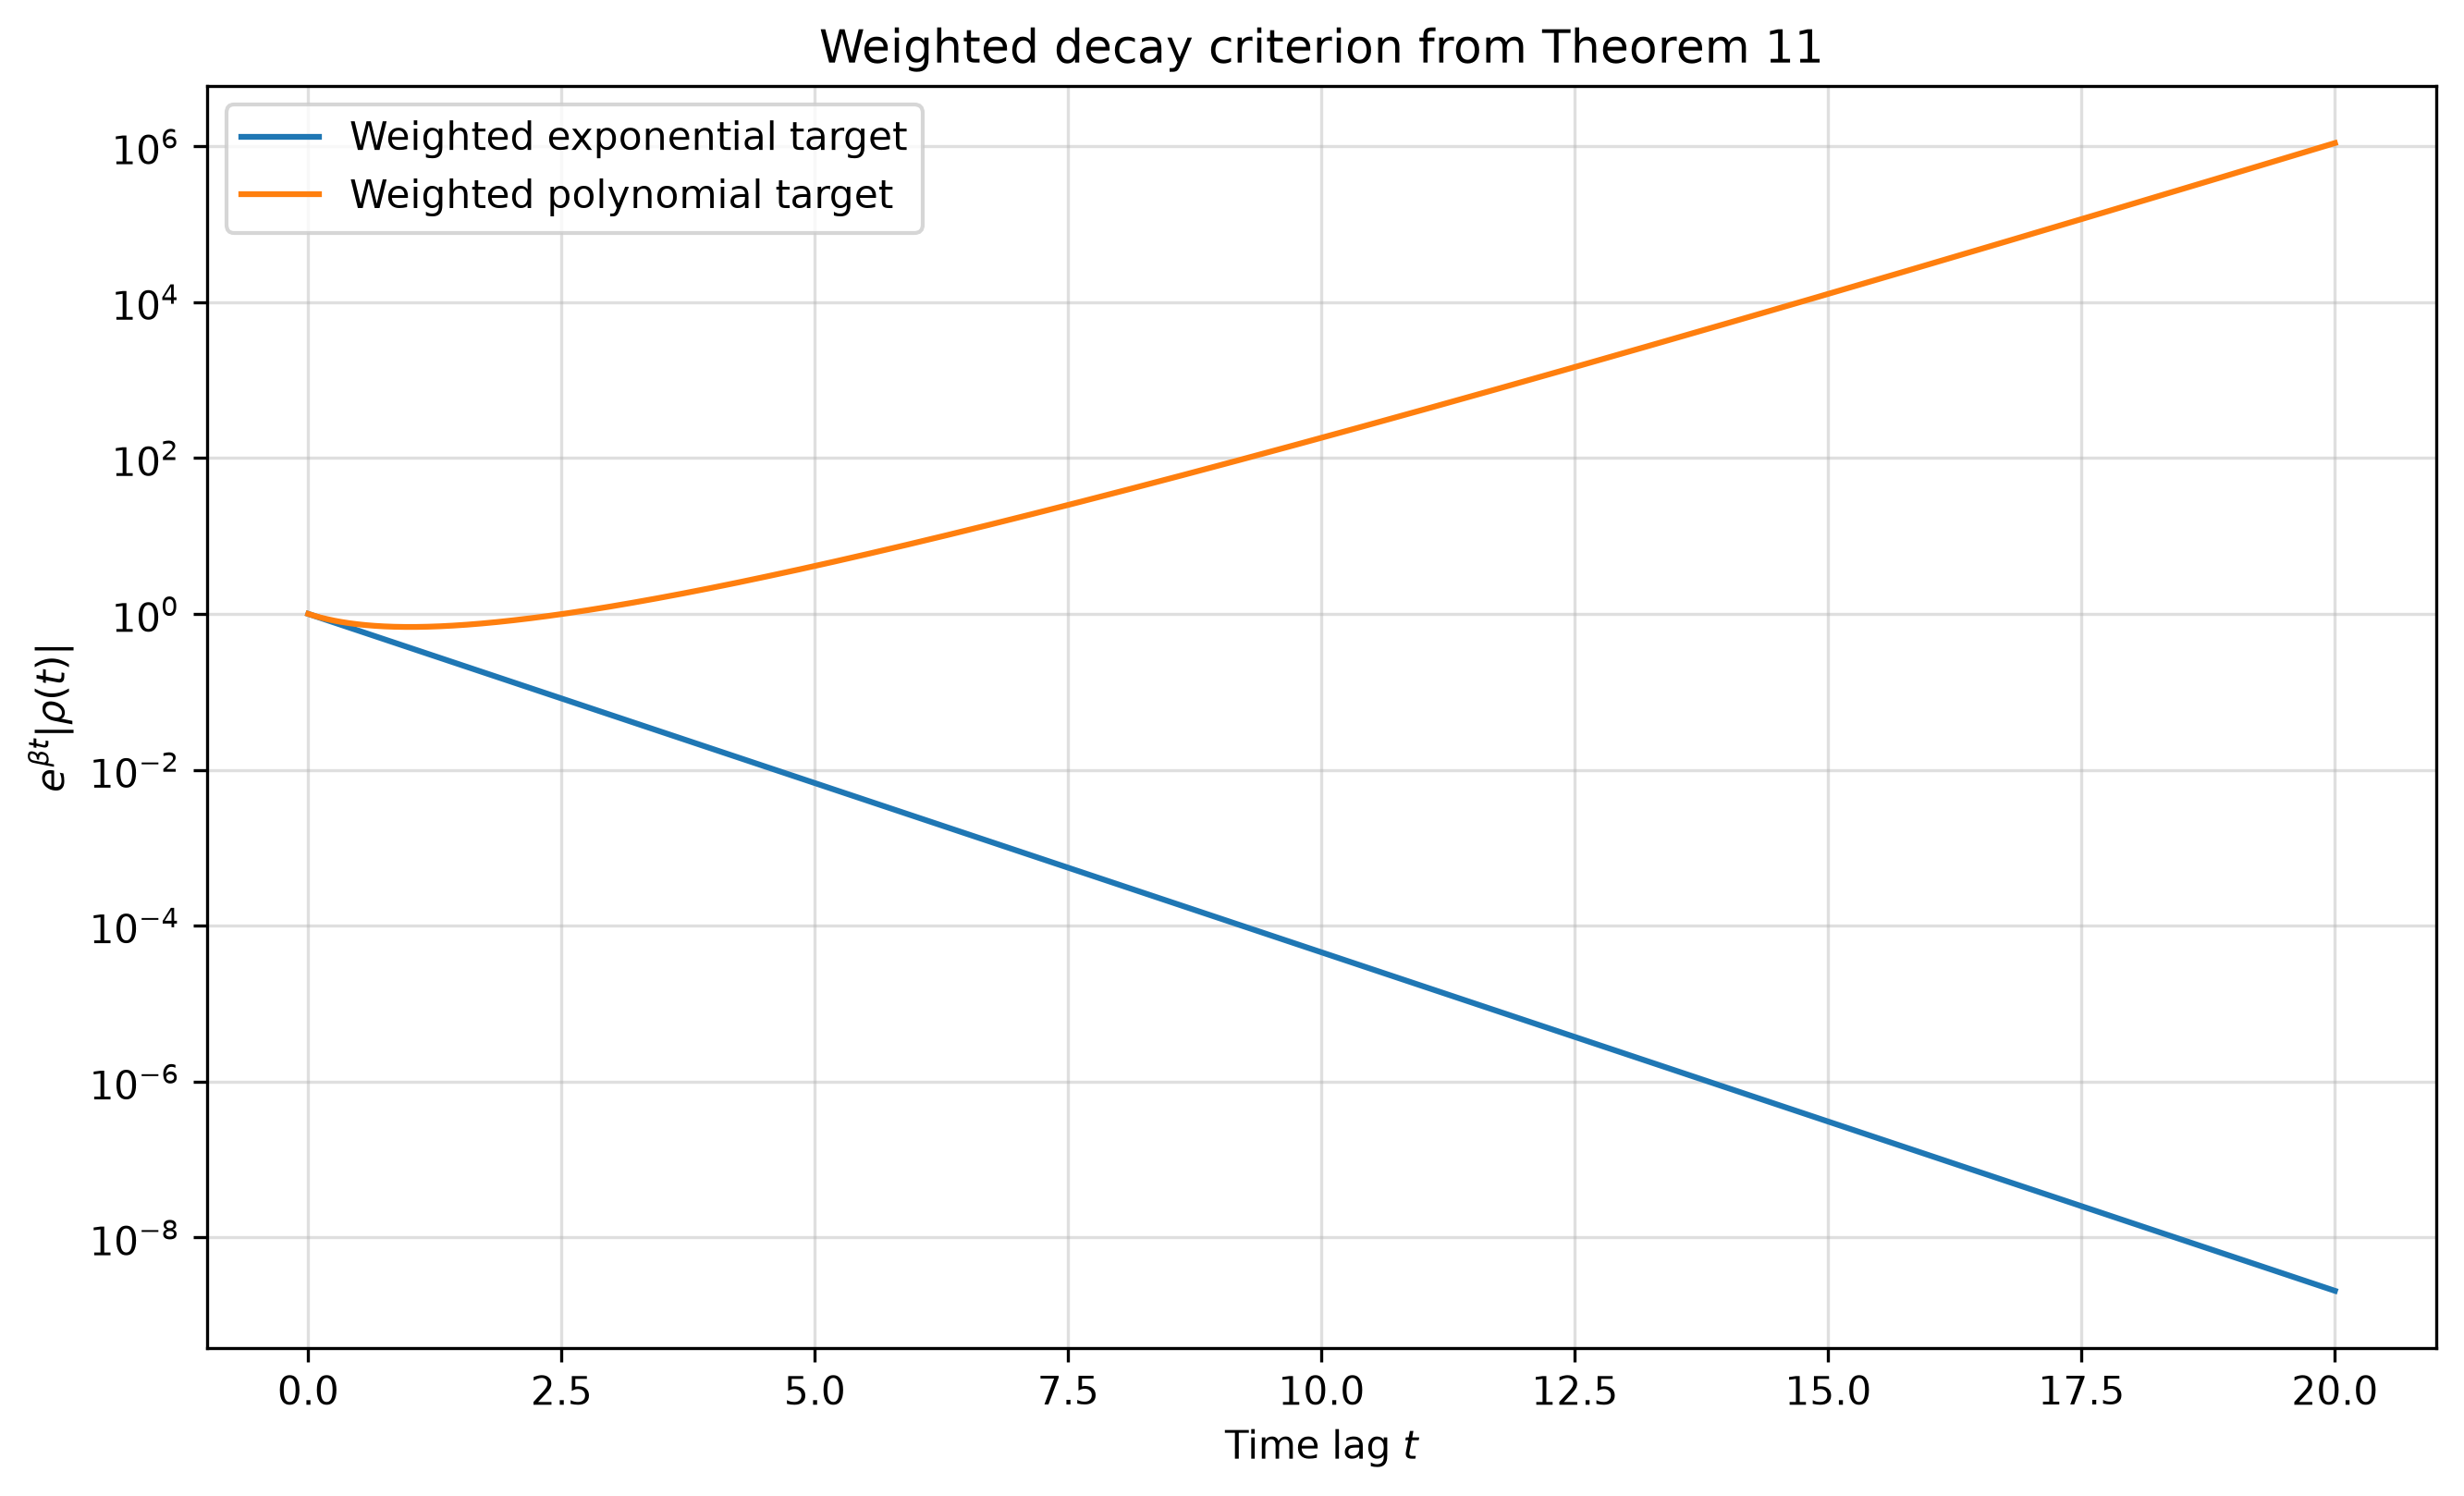

In [18]:
display(
    Image(
        filename=str(
            FIGURE_DIR
            / "theorem11_weighted_decay_criterion.png"
        )
    )
)


## 6. Role of the stability gap

Theorem 11 assumes a uniform stability margin,

$$
\limsup_{m\to\infty}\omega_m<-\beta,
$$

where

$$
\omega_m=\max_{j\in[m]}\operatorname{Re}(\lambda_j).
$$

Equivalently, all decay rates satisfy

$$
\lambda_j\ge\beta>0.
$$

For the polynomial target, we compare the theorem-compliant choice

$$
\lambda_{\min}=1
$$

with

$$
\lambda_{\min}(m)=\frac{1}{m},
$$

which violates the common stability margin by letting $\lambda_{\min}\to0$ as $m\to\infty$.

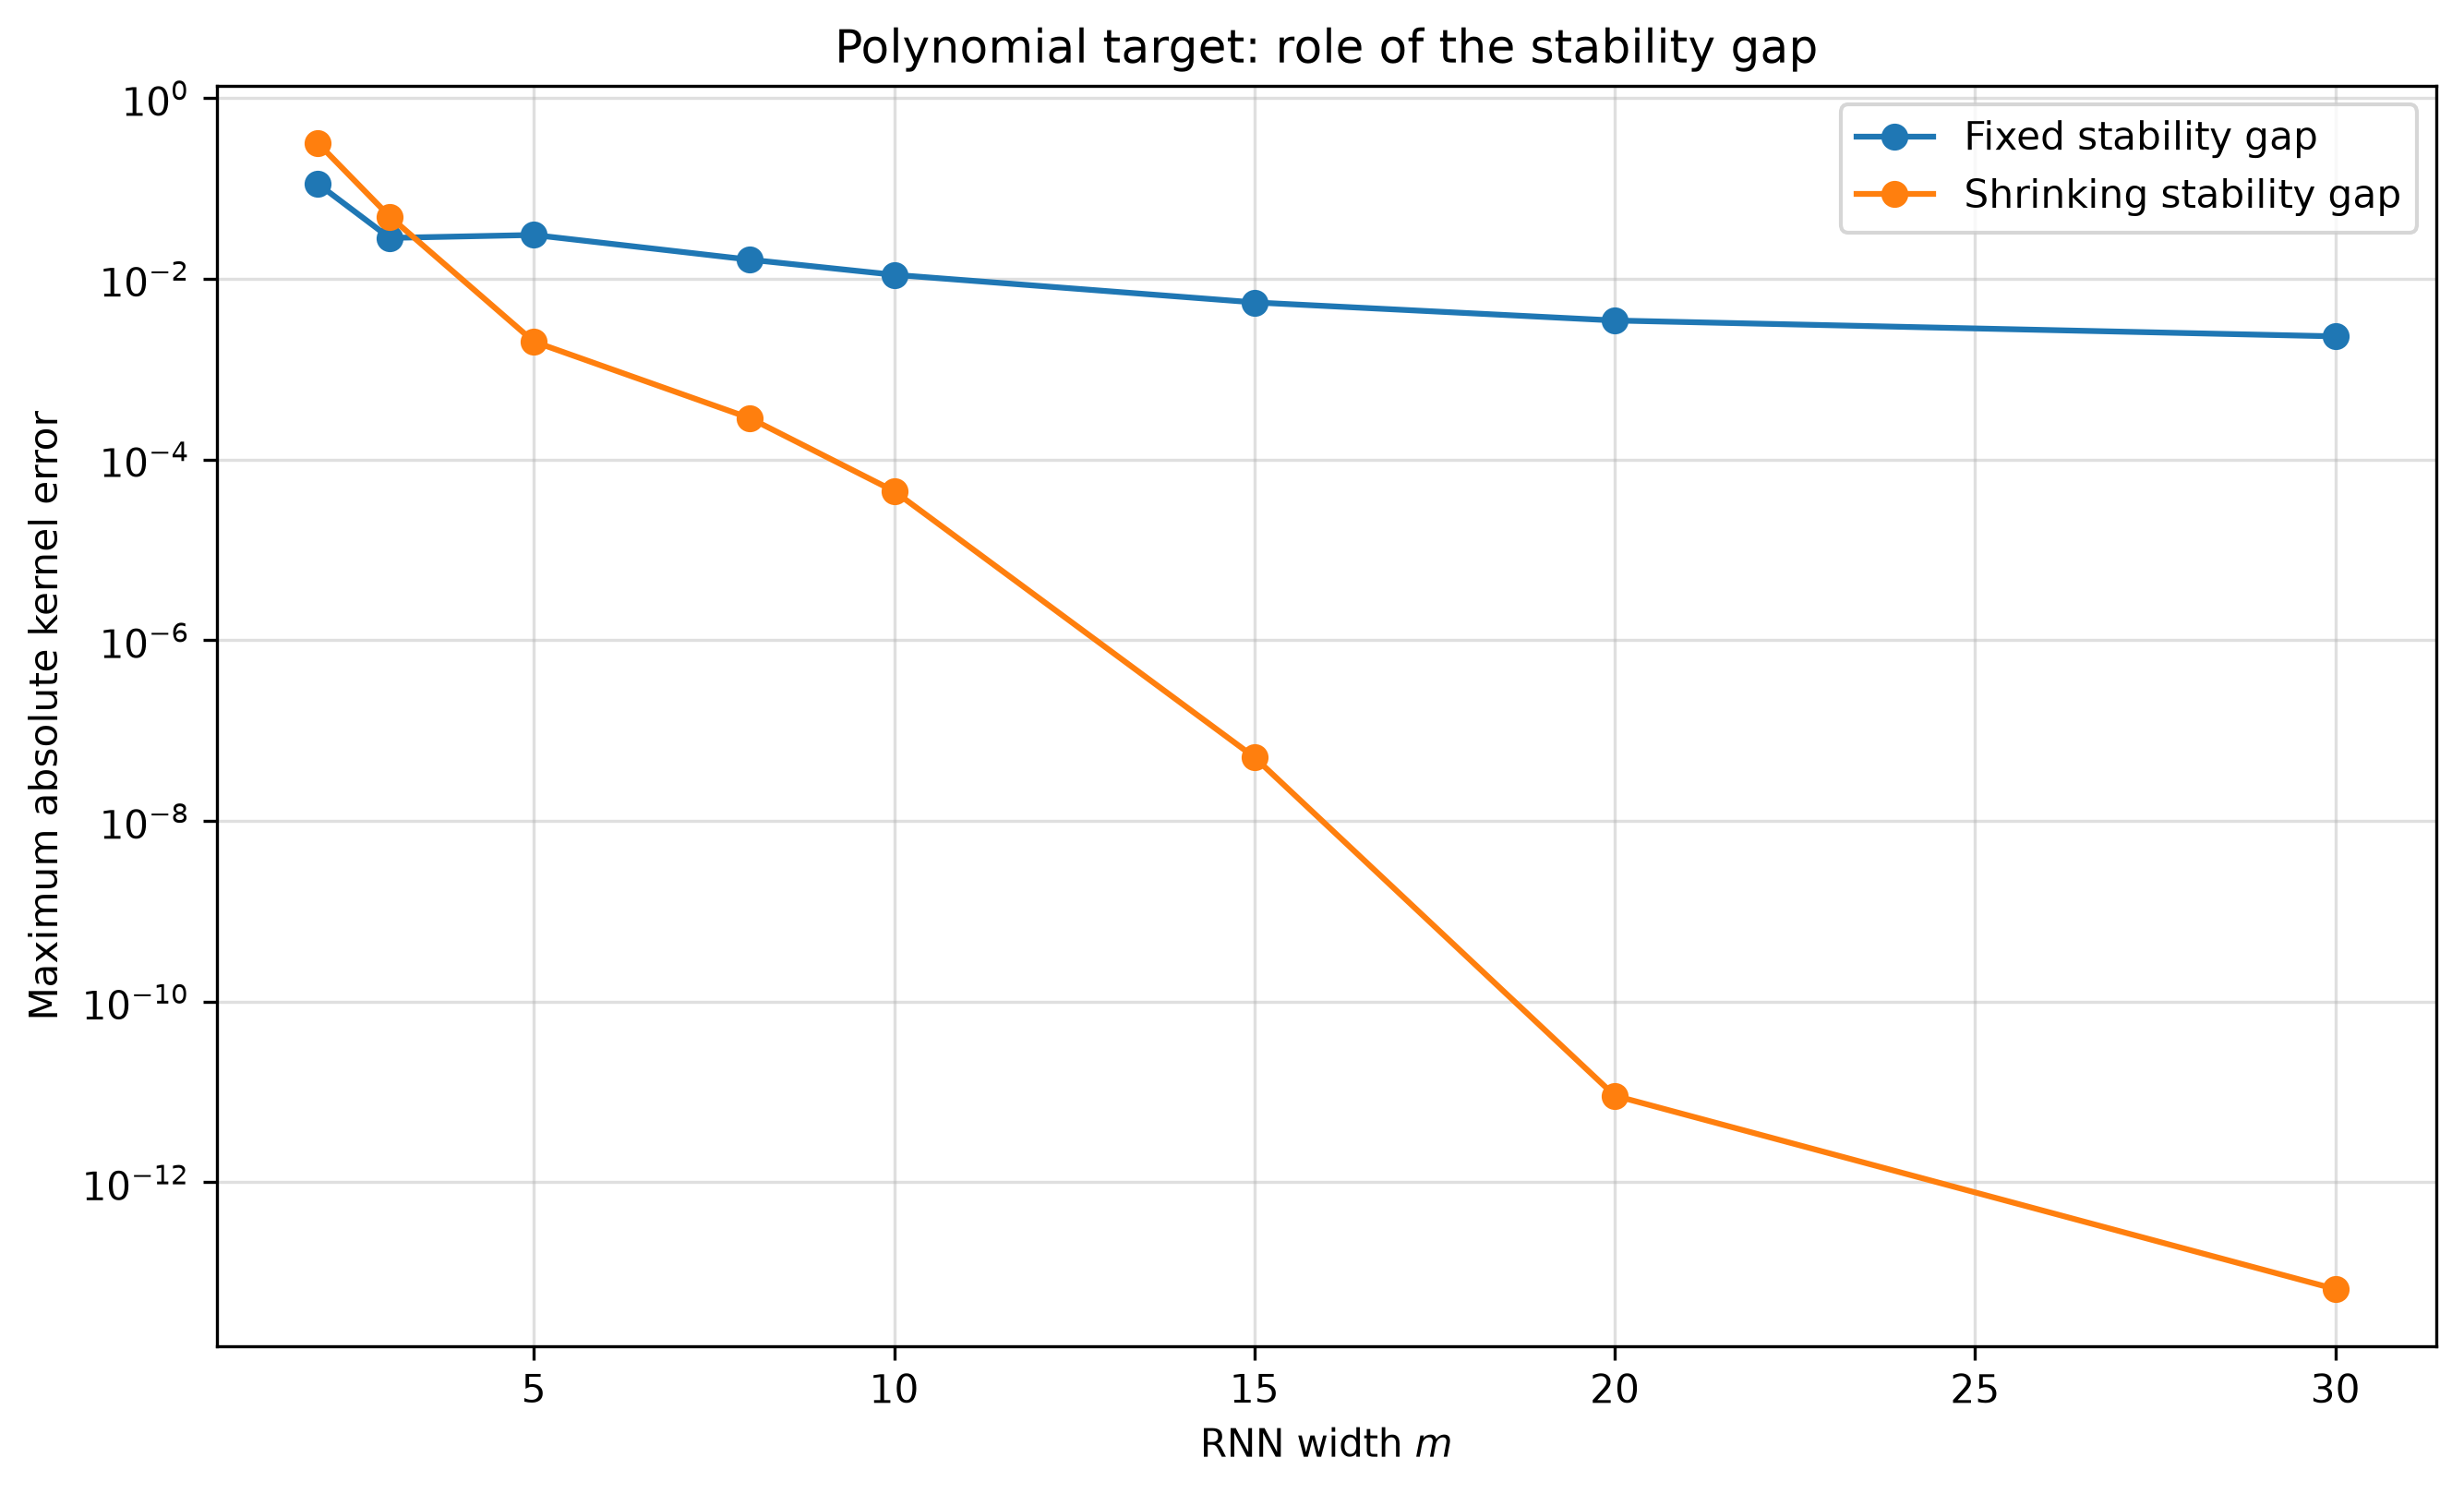

In [19]:
display(
    Image(
        filename=str(
            FIGURE_DIR
            / "theorem11_stability_gap_comparison.png"
        )
    )
)


### Interpretation

With a fixed stability gap ($\lambda_j\ge1$), the approximation error decreases only slowly because every basis function decays exponentially, while the target has a polynomial tail.

Allowing the smallest decay rate to shrink,

$$
\lambda_{\min}(m)=\frac1m\to0,
$$

introduces increasingly slow exponentials. The approximation error then decreases by many orders of magnitude.

This experiment illustrates why the uniform stability margin is essential in Theorem 11: once it is removed, slowly decaying kernels can be approximated arbitrarily well by using exponentials with vanishing decay rates.

Although the shrinking-gap model approximates the polynomial target much better, it violates the uniform stability assumption required in Theorem 11.

Without a fixed $\beta>0$, we lose the uniform tail estimate

$$
e^{\beta t}
\left|
\widehat y_{i,m}^{(k)}(t)
\right|
\le
C e^{-\delta t},
$$

which is needed to control the transformed approximations near $s=0$ and prove that they form a Cauchy sequence in $C([0,1])$.

Thus, the approximation improves, but the key step in the proof breaks down.

## 7. Numerical summary


In [20]:
summary = results.copy()

summary.columns = [
    "Width",
    "Exponential target, fixed gap",
    "Polynomial target, fixed gap",
    "Polynomial target, shrinking gap",
    "Smallest shrinking-gap rate",
]

summary


,Width,"Exponential target, fixed gap","Polynomial target, fixed gap","Polynomial target, shrinking gap",Smallest shrinking-gap rate
0,2,2.454936e-01,0.112496,3.181705e-01,0.500000
1,3,9.169279e-02,0.028232,4.863566e-02,0.333333
2,5,1.570514e-03,0.030446,2.008098e-03,0.200000
3,8,1.353110e-04,0.016206,2.855385e-04,0.125000
4,10,2.915146e-06,0.011036,4.450707e-05,0.100000
5,15,1.351752e-08,0.005460,5.053517e-08,0.066667
6,20,3.283107e-11,0.003444,9.087620e-12,0.050000
7,30,2.282619e-13,0.002298,6.583623e-14,0.033333


### Interpretation

The experiment provides a concrete example showing why the uniform stability-gap assumption in Theorem 11 is needed.

With a fixed gap, all admissible kernels decay at least exponentially, and the polynomial target cannot be approximated arbitrarily well.

If the gap is allowed to shrink, then $\lambda_{\min}(m)\to0$, increasingly slow modes become available, and the polynomial target can be approximated very accurately on the finite interval.

Thus, the assumption is not merely technical: it is what forces the approximating RNN family to retain a uniform exponential decay rate and makes the inverse conclusion of Theorem 11 possible.

## 8. Limitations

- The kernels are synthetic and known explicitly.
- The fit is performed on the finite interval $[0,20]$.
- Only diagonal exponential bases are considered.
- The experiment studies approximation, not training from noisy input-output data.
- The shrinking-gap experiment demonstrates finite-interval approximation and does not imply exact global representation on $[0,\infty)$.


## 9. Reference

Li, Z., Han, J., E, W., and Li, Q. (2022).  
*Approximation and Optimization Theory for Linear Continuous-Time RNNs*.  
Journal of Machine Learning Research, 23.
